In [110]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

In [53]:
%matplotlib widget
plt.close('all')

In [54]:
annealing_data = "data/annealing"
data_raw = np.loadtxt(os.path.join(annealing_data, "data_20nm_annealing.txt"))


In [55]:
print(data_raw)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [8.966113e+03 9.900000e+37]
 [8.966498e+03 9.900000e+37]
 [8.966888e+03 9.900000e+37]]


In [56]:
#rimuovo gli zeri e i dati di overload
mask = (data_raw[:, 1] != 0) & (data_raw[:, 1] < 1e3)
data_clean = data_raw[mask]

In [57]:
print(data_clean)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [8.838188e+03 8.075347e+02]
 [8.838258e+03 8.089226e+02]
 [8.838327e+03 8.129338e+02]]


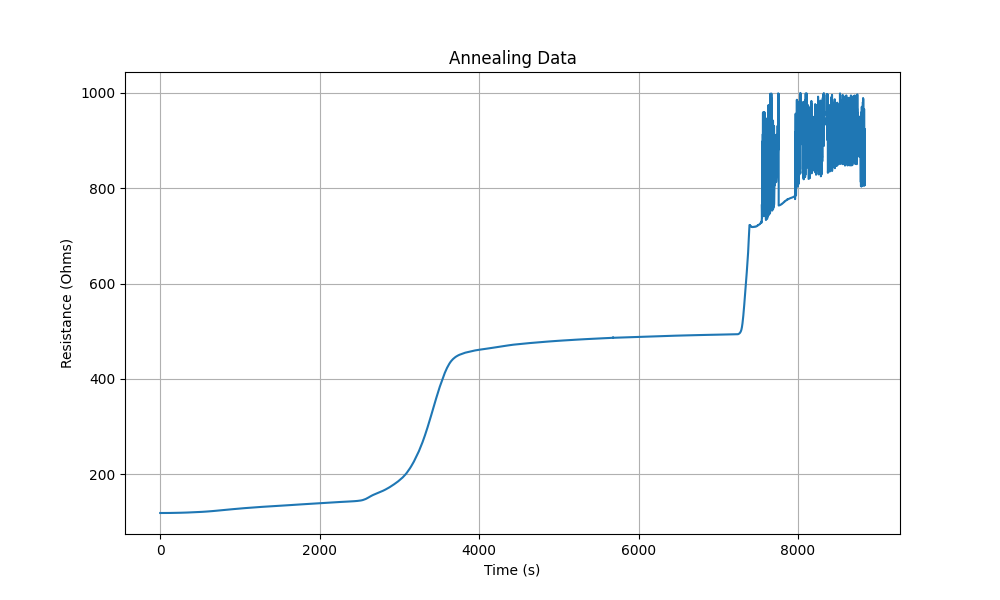

In [58]:
plt.figure(figsize=(10, 6))
plt.plot(data_clean[:, 0], data_clean[:, 1])
plt.title("Annealing Data")
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.grid()
plt.show()

In [59]:
#tengo solo i dati della curva percolativa
mask_perc = (data_clean[:, 0] < 7.24e3) & (data_clean[:, 1] > 0)
data_perc = data_clean[mask_perc]

In [60]:
print(data_perc)

[[0.000000e+00 1.188206e+02]
 [7.023191e-02 1.188229e+02]
 [1.368880e-01 1.188221e+02]
 ...
 [7.239795e+03 4.936693e+02]
 [7.239862e+03 4.936699e+02]
 [7.239931e+03 4.936702e+02]]


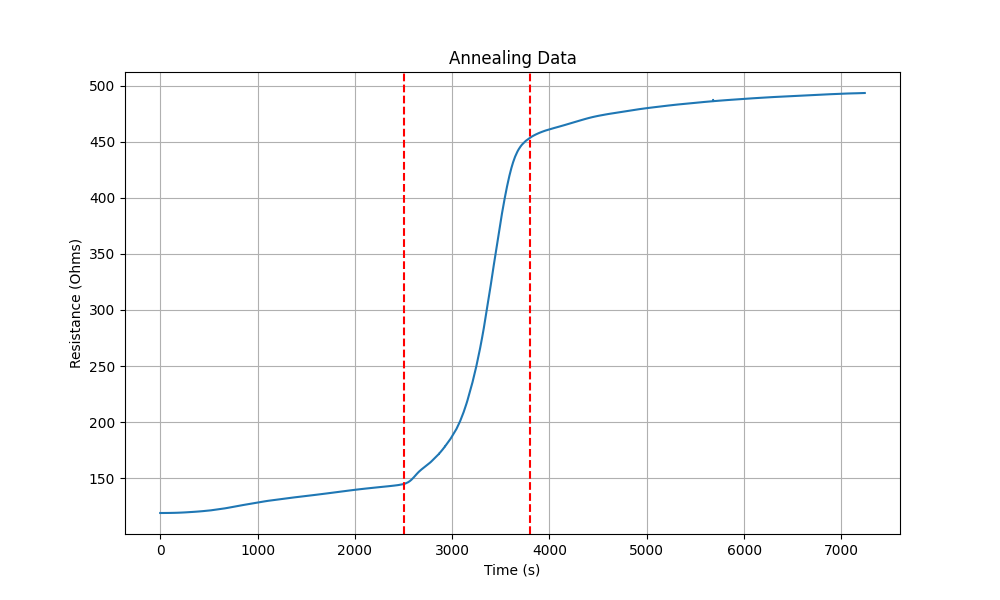

In [61]:
plt.figure(figsize=(10, 6))
plt.plot(data_perc[:, 0], data_perc[:, 1])
plt.title("Annealing Data")
plt.xlabel("Time (s)")
plt.ylabel("Resistance (Ohms)")
plt.axvline(2.5e3, color="red", linestyle="--")
plt.axvline(3.8e3, color="red", linestyle="--")
plt.grid()
plt.show()

Sembra esserci un aumento lineare della resistenza nel tempo prima dei 2500 s.
Nello stesso intervallo di tempo anche la T sembra avere un andamento lineare.
Verifichiamo l'ipotesi che in questo intervallo di tempo si ha una relazione di proporzionalità tra la R e la T.

In [62]:
#selezione dei dati di interesse
mask_linear = data_perc[:, 0] < 2.5e3
data_linear = data_perc[mask_linear]

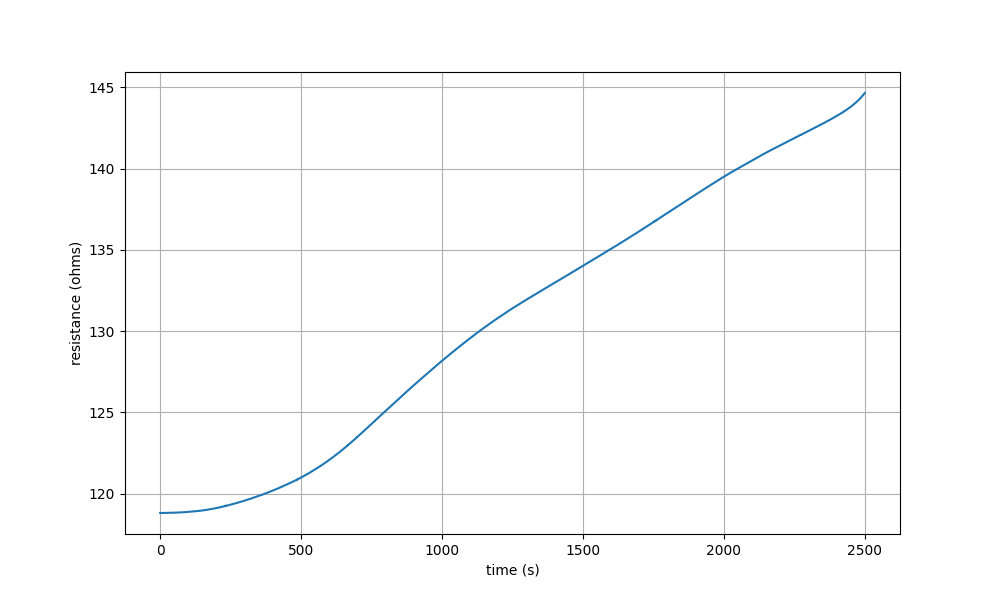

In [63]:
plt.figure(figsize=(10, 6))
plt.plot(data_linear[:, 0], data_linear[:, 1])
plt.xlabel("time (s)")
plt.ylabel("resistance (ohms)")
plt.grid()
plt.show()

In [64]:
m,q = np.polyfit(data_linear[:, 0], data_linear[:, 1], 1)
print(m,q)

0.011370919415663214 116.55305797792427


In [65]:
R_fit = m*data_linear[:,0] + q
plt.plot(data_linear[:,0], R_fit)
plt.axvline(1690, color="red", linestyle="--")

In [99]:
data_time_temp_20nm = np.loadtxt(os.path.join(annealing_data, "time_temp_20nm.txt"))

temp_interp_linear_region = np.array(np.interp(data_linear[:,0], data_time_temp_20nm[:,0], data_time_temp_20nm[:,1]))
temp_interp_all = np.array(np.interp(data_clean[:,0], data_time_temp_20nm[:,0], data_time_temp_20nm[:,1]))
temp_interp_perc = np.array(np.interp(data_perc[:,0], data_time_temp_20nm[:,0], data_time_temp_20nm[:,1]))

In [102]:
print(len(temp_interp_all))
print(len(temp_interp_perc))
print(len(data_clean[:,1]))


print(len(temp_interp_linear_region))
print(len(data_linear[:,1]))



128404
105697
128404
36482
36482


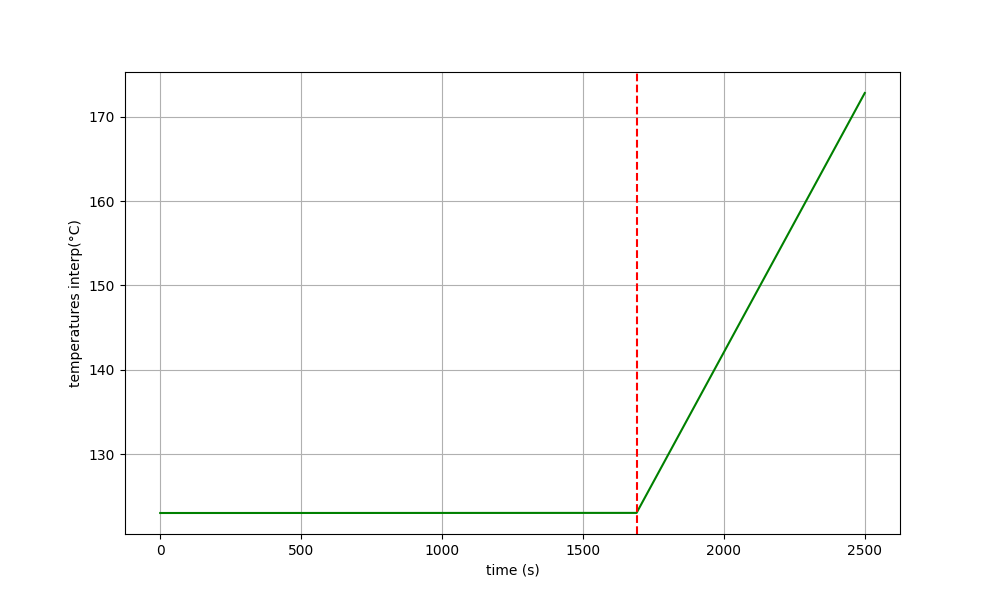

In [87]:
plt.figure(figsize=(10,6))
plt.plot(data_linear[:,0], temp_interp_linear_region, color="green")
plt.axvline(1690, color="red", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("temperatures interp(°C)")
plt.grid()
plt.show()

/tmp/ipykernel_16947/4182872127.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,6))


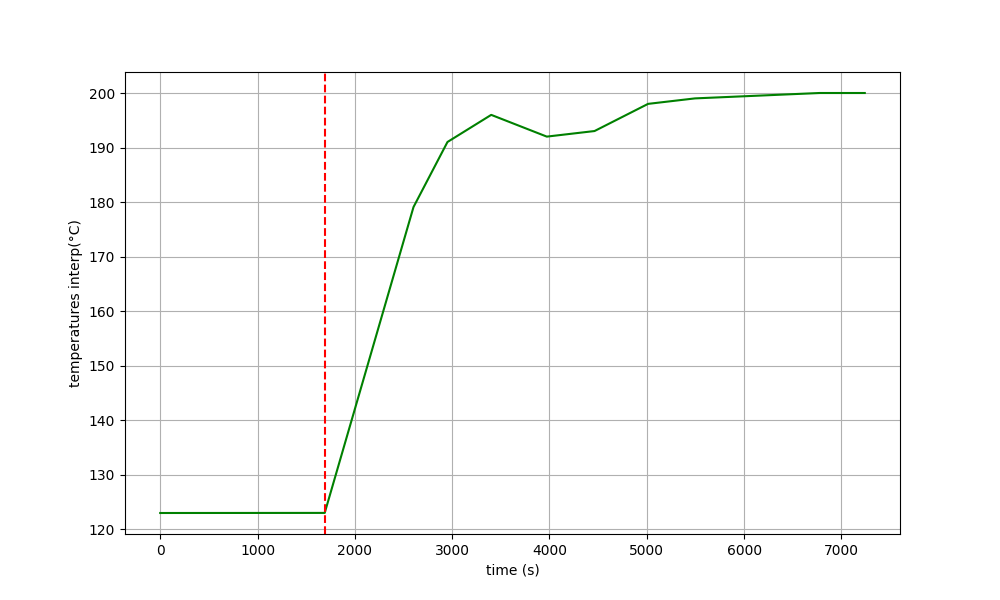

In [103]:
plt.figure(figsize=(10,6))
plt.plot(data_perc[:,0], temp_interp_perc, color="green")
#plt.plot(data_clean[:,0], temp_interp_all, color="blue")
plt.axvline(1690, color="red", linestyle="--")
plt.xlabel("time (s)")
plt.ylabel("temperatures interp(°C)")
plt.grid()
plt.show()

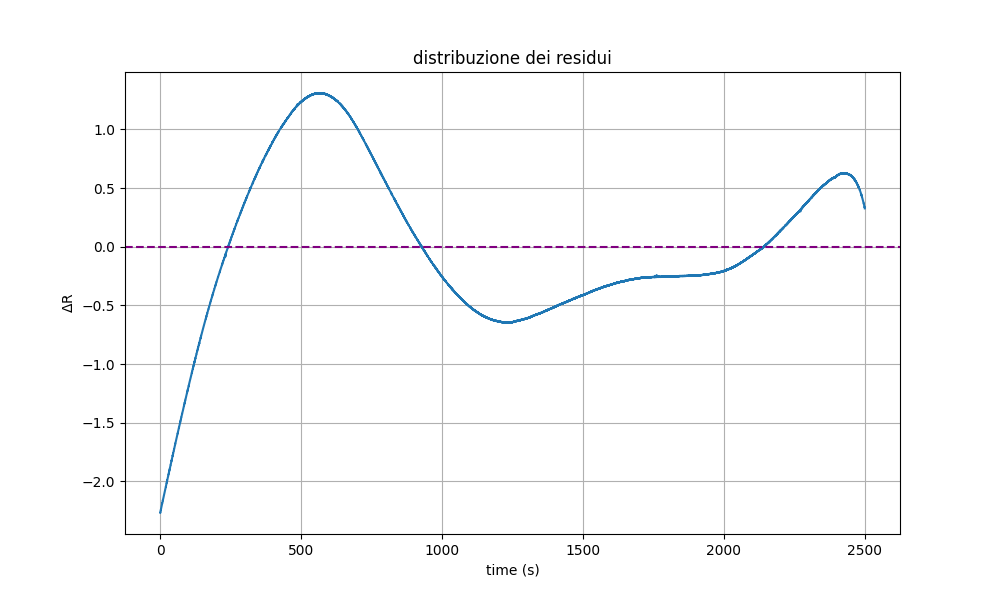

In [90]:
diff_R = R_fit - data_linear[:,1]

plt.figure(figsize=(10,6))
plt.plot(data_linear[:,0], diff_R)
plt.title("distribuzione dei residui")
plt.ylabel("$\Delta$R")
plt.xlabel("time (s)")
plt.axhline(0, color="purple", linestyle="--")
plt.grid()
plt.show()

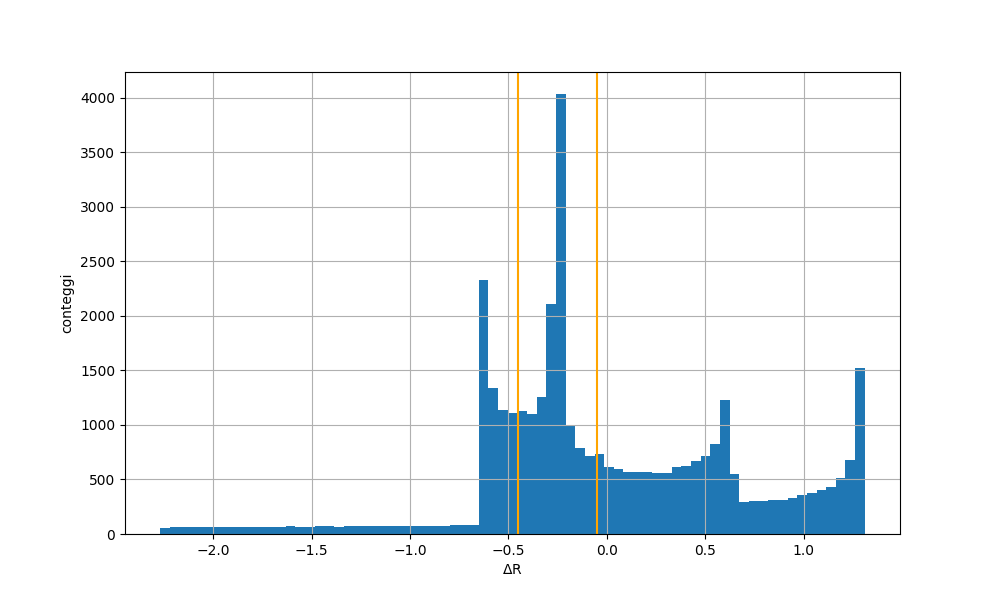

In [91]:
plt.figure(figsize=(10,6))
N = round(len(diff_R)/500) #nbins
plt.hist(diff_R, N)

mask_gaussian = (diff_R < -0.05) & (diff_R > -0.45)
diff_R_masked = diff_R[mask_gaussian]

#plt.hist(diff_R_masked, round(len((diff_R_masked/100))), color="green")
plt.axvline(-0.45, color="orange")
plt.axvline(-0.05, color="orange")
plt.ylabel("conteggi")
plt.xlabel("$\Delta$R")
plt.grid()
plt.show()

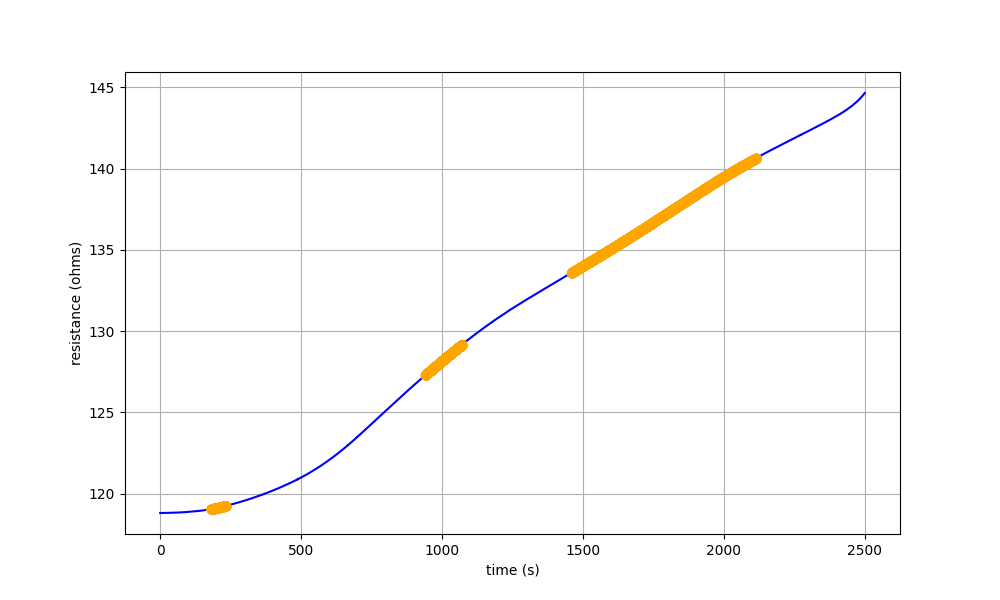

In [92]:
data_res_exp_masked = data_linear[:,1][mask_gaussian]
data_time_exp_masked = data_linear[:,0][mask_gaussian]

plt.figure(figsize=(10,6))
plt.plot(data_linear[:,0], data_linear[:,1], color="blue")
plt.plot(data_time_exp_masked, data_res_exp_masked, color="orange", linestyle="None", marker="o")
plt.xlabel("time (s)")
plt.ylabel("resistance (ohms)")
plt.grid()
plt.show()



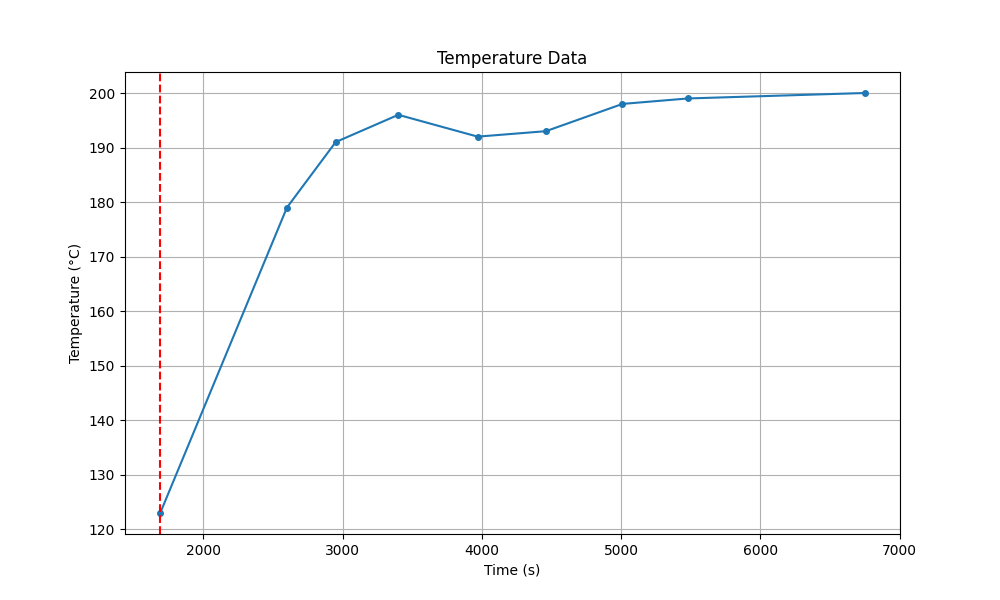

In [72]:
plt.figure(figsize=(10, 6))
plt.plot(data_time_temp_20nm[:, 0], data_time_temp_20nm[:, 1], marker='o', markersize=4, linestyle='-')
plt.title("Temperature Data")
plt.xlabel("Time (s)")
plt.ylabel("Temperature (°C)")
plt.axvline(1690, color="red", linestyle="--" )
plt.grid()
plt.show()

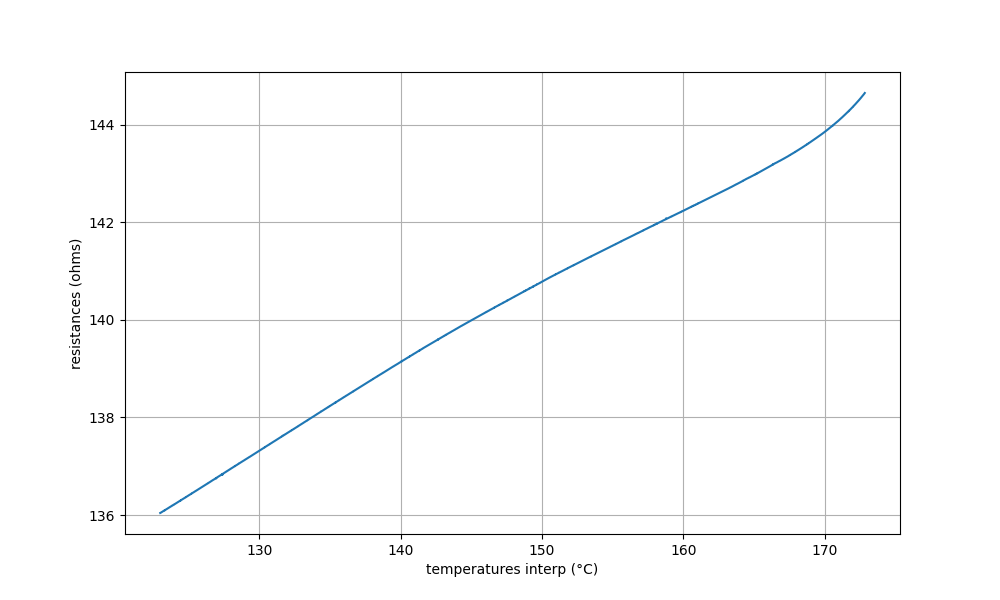

In [ ]:
#plotto solo per tempi maggiori di 1690 s nella regione linere della curva percolativa
mask_over1690 = data_linear[:,0]>1690
data_linear_over1690 = data_linear[mask_over1690]
#print(len(data1_over1690))
temp_interp_linear_over1690s = temp_interp_linear_region[mask_over1690]
#print(len(temp_interp_over1690s))

plt.figure(figsize=(10,6))
plt.plot(temp_interp_linear_over1690s, data_linear_over1690[:,1])
plt.xlabel("temperatures interp (°C)")
plt.ylabel("resistances (ohms)")
plt.grid()
plt.show()


In [94]:
m1, q1 = np.polyfit(temp_interp_linear_over1690s, data_linear_over1690[:,1], 1)
print(m1,q1)

y_fit = m1 * temp_interp_linear_over1690s +q1
plt.plot(temp_interp_linear_over1690s, y_fit, color="orange")

0.16357353331959892 116.12389111821055


81036
81036


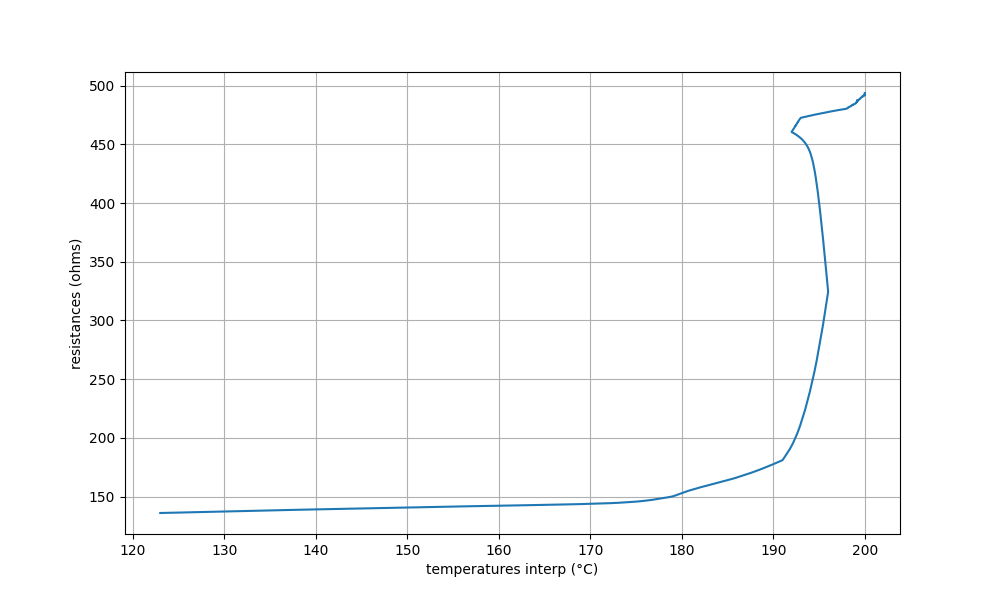

In [104]:
mask4 = data_perc[:,0]>1690
data_perc_over1690 = data_perc[mask4]
temp_interp_perc_over1690 = temp_interp_perc[mask4]
print(len(data_perc_over1690))
print(len(temp_interp_perc_over1690))

plt.figure(figsize=(10,6))
plt.plot(temp_interp_perc_over1690, data_perc_over1690[:,1])
plt.xlabel("temperatures interp (°C)")
plt.ylabel("resistances (ohms)")
plt.grid()
plt.show()


11146
11146


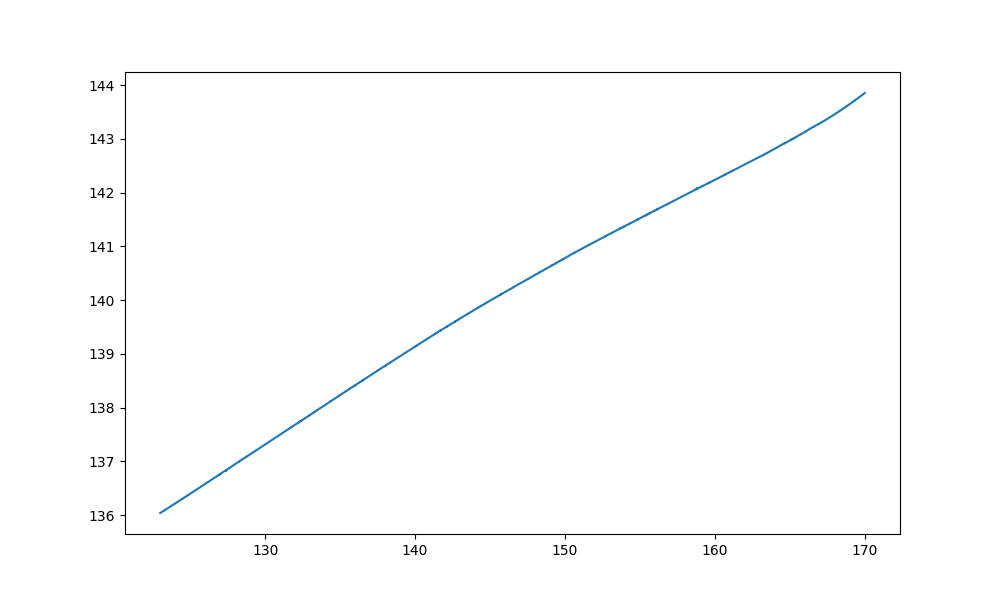

In [107]:
#prendo i dati fino a T < 170 °C

mask5 = temp_interp_perc_over1690<170
data_perc_fit = data_perc_over1690[mask5]
temp_interp_perc_fit = temp_interp_perc_over1690[mask5]
print(len(data_perc_fit))
print(len(temp_interp_perc_fit))

plt.figure(figsize=(10,6))
plt.plot(temp_interp_perc_fit, data_perc_fit[:,1])


In [117]:
def f(x,alfa,q):
    return alfa*118*x+q


In [118]:
results = sp.optimize.curve_fit(f,temp_interp_perc_fit, data_perc_fit[:,1])
print(results)

(array([1.38220749e-03, 1.16189876e+02]), array([[ 4.25303695e-13, -7.35141504e-09],
       [-7.35141504e-09,  1.28161464e-04]]))


In [ ]:
devst = np.sqrt(results[1])
print(devst)  

[[6.52153123e-07            nan]
 [           nan 1.13208420e-02]]


/tmp/ipykernel_16947/1121753298.py:1: RuntimeWarning: invalid value encountered in sqrt
  devst = np.sqrt(results[1])


In [77]:
#calcolo errori

sigmaR = np.std(diff_R_masked)
print(sigmaR)

sigmaT = 0.5 

0.09115229704436567


In [78]:
def calcolo_errori_percentuali(res, filepath, filename):
    data_errori = np.loadtxt(os.path.join(filepath, filename))
    data_container = np.zeros((res.shape[0], data_errori.shape[1])) #tre colonne e tante righe quante sono i dati di resistenza misurati
    for i in range(len(res)):
        odg = np.floor(np.log10(np.abs(res[i,1])))
        data_container[i, 0] = odg+1
        idx = data_container[i,0] - 2 
        data_container[i, 1:] = data_errori[int(idx), 1:] #riempio le ultime due colonne dell'i-esima riga
    return data_container

def exp_err (res, data_container):
    exp_err = []
    for i in range(len(res)):
        exp_err.append(res[i, 1]* data_container[i,1] + data_container[i,0] * data_container[i,2]) 
    return exp_err
    

In [79]:
error_data_container = calcolo_errori_percentuali(data, annealing_data, "dati_calcolo_exp_err.txt")
exp_err_res = exp_err(data, error_data_container)

In [80]:
print(exp_err_res)

[1.191206, 1.1912289999999999, 1.191221, 1.191212, 1.1912129999999999, 1.191217, 1.191215, 1.191217, 1.191211, 1.191212, 1.191214, 1.19122, 1.191215, 1.191207, 1.1912099999999999, 1.1912129999999999, 1.191207, 1.191214, 1.191216, 1.191214, 1.191216, 1.1912129999999999, 1.19122, 1.1912099999999999, 1.1912099999999999, 1.1912049999999998, 1.1912049999999998, 1.1912019999999999, 1.191215, 1.191198, 1.191215, 1.191221, 1.191208, 1.191208, 1.191199, 1.191211, 1.191208, 1.191193, 1.191211, 1.191206, 1.1911969999999998, 1.191203, 1.1911969999999998, 1.191196, 1.191204, 1.1911999999999998, 1.1911969999999998, 1.191185, 1.1911999999999998, 1.1911939999999999, 1.191196, 1.191203, 1.1911939999999999, 1.191193, 1.191196, 1.1911859999999999, 1.191193, 1.1911829999999999, 1.191195, 1.1911909999999999, 1.1911889999999998, 1.1911889999999998, 1.191188, 1.191187, 1.19118, 1.191185, 1.191187, 1.1911839999999998, 1.191187, 1.1911889999999998, 1.191185, 1.1911789999999998, 1.1911789999999998, 1.1911919999

In [81]:
mean_exp_err_res = np.mean(exp_err_res)
print(mean_exp_err_res)

3.2171310911567974


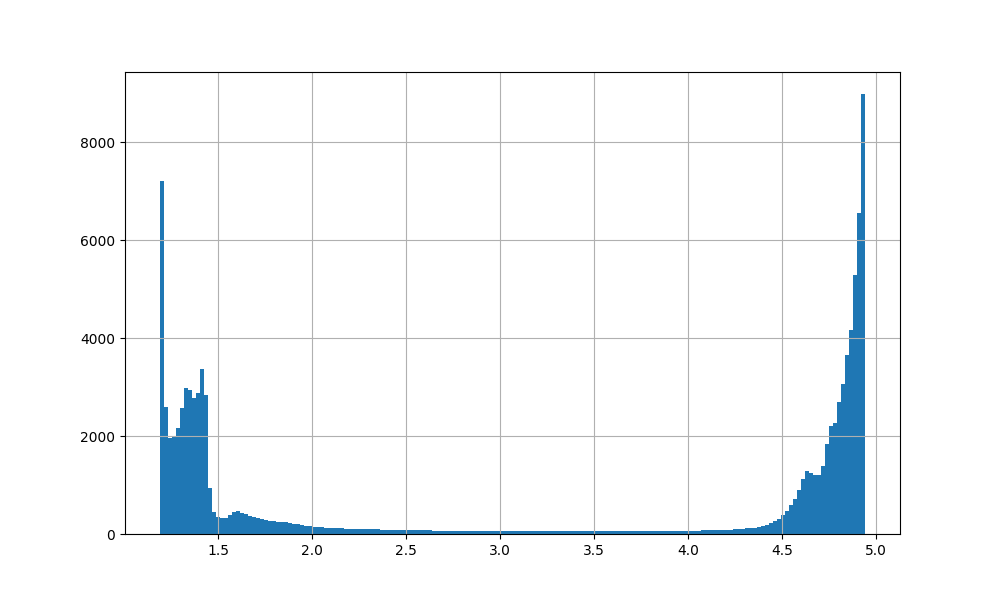

In [82]:
plt.figure(figsize=(10,6))
Nbins = round(len(exp_err_res)/600)
plt.hist(exp_err_res, Nbins)
plt.grid()
plt.show()

In [83]:
valori, occorrenze = np.unique(exp_err_res, return_counts=True)

indice_moda = np.argmax(occorrenze)
moda = valori[indice_moda]

print(moda)

1.191249
